In [1]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("库导入完成！")


库导入完成！


In [2]:
# 导入数据集
df = pd.read_csv('train_risked.csv')

print("数据集导入完成！")
print(f"数据集形状: {df.shape}")
print(f"列数: {df.shape[1]}")
print(f"行数: {df.shape[0]}")

# 显示前几行数据
print("\n数据集前5行:")
df.head()

数据集导入完成！
数据集形状: (11167, 35)
列数: 35
行数: 11167

数据集前5行:


,线路类型,是否c2c,是否生鲜妥投及时,保价金额,始发城市,目的城市,寄件人id,收件人id,寄件是否内部,配送超时时长,...,进线渠道_编码,商品类型_编码,进线人身份_编码,妥投到进线时长_分桶,虚报比例,生鲜妥投组合类别_编码,始发网点类别_target_encoded,目的网点类别_target_encoded,数分位指标,风险标注
0,2,0,0,1.402,146,125,183889,300000,-1,427863,...,2,1,0,6,0.847558,2,247.542000,275.807187,5.521682,诉求偏高
1,2,1,0,0.971,309,117,147363,300000,-1,427847,...,0,12,0,6,0.863044,2,266.890864,203.056609,6.255585,诉求偏高
2,2,0,0,56.729,134,4,21570,146233,-1,-23039,...,0,0,1,5,0.661562,2,307.815571,323.682986,1.938513,合理诉求
3,2,0,1,66.737,229,222,226496,308949,-1,427699,...,2,11,1,6,0.716788,2,272.366911,242.464279,2.497561,合理诉求
4,2,0,0,11.434,179,168,122138,50377,-1,427758,...,4,11,0,0,0.859500,2,231.203247,245.121692,5.853068,诉求偏高


In [3]:
# 对风险标注列进行数值编码
# 在当前风险标准中，风险标注分为合理诉求、诉求偏高、严重超额三类，对其进行数值编码
risk_label_map = {'合理诉求': 0, '诉求偏高': 1, '严重超额': 2}
if '风险标注' in df.columns:
    df['风险标注_编码'] = df['风险标注'].map(risk_label_map)
    print("风险标注采用数值编码，映射如下：")
    print(risk_label_map)
    print("\n编码后的风险标注列:")
    print(df['风险标注_编码'].value_counts().sort_index())
    print("\n原始风险标注列:")
    print(df['风险标注'].value_counts())
    

风险标注采用数值编码，映射如下：
{'合理诉求': 0, '诉求偏高': 1, '严重超额': 2}

编码后的风险标注列:
风险标注_编码
0    9493
1    1339
2     335
Name: count, dtype: int64

原始风险标注列:
风险标注
合理诉求    9493
诉求偏高    1339
严重超额     335
Name: count, dtype: int64


In [4]:
# 数据预处理和特征工程
# 分离特征和目标变量
target_column = '风险标注_编码'
print("数据集已有数据列如下：")
print(df.columns.tolist())

# 由用户自定义特征列，请根据需求修改如下
feature_columns = [
    '线路类型', '是否c2c', '保价金额', '寄件是否内部', '配送超时时长', '妥投到进线时长', '索赔金额', '新旧程度', 
     '异常原因_编码', '进线渠道_编码', '商品类型_编码', '进线人身份_编码', '妥投到进线时长_分桶','生鲜妥投组合类别_编码', 
     '始发网点万单理赔率','目的网点万单理赔率']
print("本次建模所选特征列如下：")
print(feature_columns)

print(f"特征列数量: {len(feature_columns)}")
print(f"目标变量: {target_column}")

# 检查特征列的数据类型
print("\n特征列数据类型:")
print(df[feature_columns].dtypes.value_counts())

# 处理缺失值
print(f"\n缺失值统计:")
missing_values = df[feature_columns].isnull().sum()
print(missing_values[missing_values > 0])
print(f"\n填充后缺失值统计:")
print(df[feature_columns].isnull().sum().sum())


数据集已有数据列如下：
['线路类型', '是否c2c', '是否生鲜妥投及时', '保价金额', '始发城市', '目的城市', '寄件人id', '收件人id', '寄件是否内部', '配送超时时长', '异常原因', '进线渠道', '妥投到进线时长', '索赔金额', '商品类型', '新旧程度', '寄件B/C', '进线人身份', '始发网点万单理赔率', '始发网点赔付比例', '目的网点万单理赔率', '目的网点赔付比例', '实际赔付金额', '理赔差额', '异常原因_编码', '进线渠道_编码', '商品类型_编码', '进线人身份_编码', '妥投到进线时长_分桶', '虚报比例', '生鲜妥投组合类别_编码', '始发网点类别_target_encoded', '目的网点类别_target_encoded', '数分位指标', '风险标注', '风险标注_编码']
本次建模所选特征列如下：
['线路类型', '是否c2c', '保价金额', '寄件是否内部', '配送超时时长', '妥投到进线时长', '索赔金额', '新旧程度', '异常原因_编码', '进线渠道_编码', '商品类型_编码', '进线人身份_编码', '妥投到进线时长_分桶', '生鲜妥投组合类别_编码', '始发网点万单理赔率', '目的网点万单理赔率']
特征列数量: 16
目标变量: 风险标注_编码

特征列数据类型:
int64      12
float64     4
Name: count, dtype: int64

缺失值统计:
Series([], dtype: int64)

填充后缺失值统计:
0


In [5]:
# 创建城市和人员相关的均值聚合特征（折外版）
print("=== 生成城市/人员相关聚合特征（折外） ===")

import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import KFold

# 暂存赔保比特征
df['赔保比_tmp'] = df['索赔金额'] / (df['保价金额'] + 1)

# 初始化所有新特征
agg_cols = [
    '始发城市_风险特征', '目的城市_风险特征', '寄件人_风险特征', '收件人_风险特征',
    '始发城市_风险标注均值', '目的城市_风险标注均值', '寄件人_风险标注均值', '收件人_风险标注均值'
]
df[agg_cols] = 0.0

kf = KFold(n_splits=5, shuffle=True, random_state=42)
print("使用5折交叉验证计算折外聚合特征...")

for fold, (idx_train, idx_valid) in enumerate(kf.split(df)):
    print(f"- 第{fold+1}折")
    train, val = df.iloc[idx_train].copy(), df.iloc[idx_valid].copy()
    
    # 聚合：赔保比
    for col_id, col_feat in zip(
        ['始发城市', '目的城市', '寄件人id', '收件人id'],
        ['始发城市_风险特征', '目的城市_风险特征', '寄件人_风险特征', '收件人_风险特征']
    ):
        g = train.groupby(col_id)['赔保比_tmp'].mean().reset_index()
        g.columns = [col_id, col_feat]
        val = val.merge(g, on=col_id, how='left', suffixes=('', '_new'))
        val[col_feat] = val[f'{col_feat}_new'].fillna(val[col_feat])
        val.drop(columns=[f'{col_feat}_new'], inplace=True)
    
    # 聚合：风险标注均值
    for col_id, col_feat in zip(
        ['始发城市', '目的城市', '寄件人id', '收件人id'],
        ['始发城市_风险标注均值', '目的城市_风险标注均值', '寄件人_风险标注均值', '收件人_风险标注均值']
    ):
        g = train.groupby(col_id)['风险标注_编码'].mean().reset_index()
        g.columns = [col_id, col_feat]
        val = val.merge(g, on=col_id, how='left', suffixes=('', '_new'))
        val[col_feat] = val[f'{col_feat}_new'].fillna(val[col_feat])
        val.drop(columns=[f'{col_feat}_new'], inplace=True)
    
    # 更新回df
    df.loc[idx_valid, agg_cols] = val[agg_cols].values

# 全局均值填充缺失
mean_val = df['赔保比_tmp'].mean()
for col in ['始发城市_风险特征','目的城市_风险特征','寄件人_风险特征','收件人_风险特征']:
    df[col] = df[col].fillna(mean_val)
# 风险标注均值的全局填充（用全局平均风险标注编码）
risk_label_mean = df['风险标注_编码'].mean()
for col in ['始发城市_风险标注均值', '目的城市_风险标注均值', '寄件人_风险标注均值', '收件人_风险标注均值']:
    df[col] = df[col].fillna(risk_label_mean)

df.drop(columns=['赔保比_tmp'], inplace=True)

print("聚合特征（折外）计算完成!")
for f in ['始发城市_风险特征', '目的城市_风险特征', '寄件人_风险特征', '收件人_风险特征']:
    print(f"{f}: 均值={df[f].mean():.4f}, std={df[f].std():.4f}")

for f in ['始发城市_风险标注均值', '目的城市_风险标注均值', '寄件人_风险标注均值', '收件人_风险标注均值']:
    print(f"{f}: 均值={df[f].mean():.4f}, std={df[f].std():.4f}")

# 特征列设置
target_column = '风险标注_编码'
feature_columns = [
    '线路类型', '是否c2c', '保价金额', '寄件是否内部', '配送超时时长', '妥投到进线时长', '索赔金额', '新旧程度',
    '异常原因_编码', '进线渠道_编码', '商品类型_编码', '进线人身份_编码', '妥投到进线时长_分桶', '生鲜妥投组合类别_编码',
     '始发网点万单理赔率', '目的网点万单理赔率',
    '始发城市_风险特征', '目的城市_风险特征', '寄件人_风险特征', '收件人_风险特征',
    '始发城市_风险标注均值', '目的城市_风险标注均值', '寄件人_风险标注均值', '收件人_风险标注均值'
]

print("全部特征列：")
print(feature_columns)
print(f"特征数量: {len(feature_columns)}；目标变量: {target_column}")

print("\n特征列类型分布:")
print(df[feature_columns].dtypes.value_counts())

# 保存含折外聚合特征的数据
df.to_csv('聚合特征增强版数据集.csv', index=False, encoding='utf-8-sig')
print("已保存增强版数据集文件: 聚合特征增强版数据集.csv")
print(df.head(10))

# 缺失值检查
print("\n缺失值统计:")
miss = df[feature_columns].isnull().sum()
print(miss[miss>0])
print(f"\n所有特征总缺失个数: {df[feature_columns].isnull().sum().sum()}")

=== 生成城市/人员相关聚合特征（折外） ===
使用5折交叉验证计算折外聚合特征...
- 第1折
- 第2折


- 第3折
- 第4折
- 第5折
聚合特征（折外）计算完成!
始发城市_风险特征: 均值=69.6052, std=36.5263
目的城市_风险特征: 均值=69.4518, std=36.4555
寄件人_风险特征: 均值=63.2112, std=100.5976
收件人_风险特征: 均值=59.5199, std=114.5598
始发城市_风险标注均值: 均值=0.1793, std=0.1105
目的城市_风险标注均值: 均值=0.1795, std=0.1106
寄件人_风险标注均值: 均值=0.1696, std=0.2694
收件人_风险标注均值: 均值=0.1646, std=0.3135
全部特征列：
['线路类型', '是否c2c', '保价金额', '寄件是否内部', '配送超时时长', '妥投到进线时长', '索赔金额', '新旧程度', '异常原因_编码', '进线渠道_编码', '商品类型_编码', '进线人身份_编码', '妥投到进线时长_分桶', '生鲜妥投组合类别_编码', '始发网点万单理赔率', '目的网点万单理赔率', '始发城市_风险特征', '目的城市_风险特征', '寄件人_风险特征', '收件人_风险特征', '始发城市_风险标注均值', '目的城市_风险标注均值', '寄件人_风险标注均值', '收件人_风险标注均值']
特征数量: 24；目标变量: 风险标注_编码

特征列类型分布:
int64      12
float64    12
Name: count, dtype: int64
已保存增强版数据集文件: 聚合特征增强版数据集.csv
   线路类型  是否c2c  是否生鲜妥投及时     保价金额  始发城市  目的城市   寄件人id   收件人id  寄件是否内部  配送超时时长  \
0     2      0         0    1.402   146   125  183889  300000      -1  427863   
1     2      1         0    0.971   309   117  147363  300000      -1  427847   
2     2      0         0   56.729   134     

In [6]:
# # 解决“严重超额”样本量不足问题: 采用上采样的方式，增加严重超额类别的样本，使三类样本数量大致平衡
#     from sklearn.utils import resample

#     majority_0 = df[df['风险标注_编码'] == 0]
#     majority_1 = df[df['风险标注_编码'] == 1]
#     minority_2 = df[df['风险标注_编码'] == 2]

#     majority_count = max(len(majority_0), len(majority_1))
#     minority_count = len(minority_2)
#     print(f"\n各类别样本数：\n合理诉求: {len(majority_0)}，诉求偏高: {len(majority_1)}，严重超额: {len(minority_2)}")

#     if minority_count > 0 and minority_count < majority_count:
#         # 对严重超额类别进行有放回的上采样
#         minority_2_upsampled = resample(
#             minority_2,
#             replace=True,
#             n_samples=majority_count,
#             random_state=42
#         )
#         df = pd.concat([majority_0, majority_1, minority_2_upsampled], axis=0).reset_index(drop=True)
#         print(f"\n已经对严重超额类别进行了上采样。上采样后各类别数量：")
#         print(df['风险标注_编码'].value_counts().sort_index())
#     elif minority_count == 0:
#         print("\n严重超额类别样本为0，无法上采样。")
#     else:
#         print("\n严重超额类别已与其他类别数目接近，无需上采样。")
# else:
#     print("风险标注列不存在，无需编码。")

In [7]:
#数据准备
print("=== 使用折外计算的特征进行模型训练 ===")

# 准备训练数据
X = df[feature_columns].copy()
y = df['风险标注_编码'].copy()

print(f"\n训练数据形状: {X.shape}")
print(f"目标变量分布:")
print(y.value_counts().sort_index())

# 检查风险特征的分布
print(f"\n风险特征分布:")
risk_features = ['始发城市_风险特征', '目的城市_风险特征', '寄件人_风险特征', '收件人_风险特征']
for feature in risk_features:
    print(f"{feature}: 均值={X[feature].mean():.4f}, 标准差={X[feature].std():.4f}, 范围=[{X[feature].min():.4f}, {X[feature].max():.4f}]")

print("\n✅ 数据准备完成！现在可以使用这些折外计算的特征进行模型训练。")


=== 使用折外计算的特征进行模型训练 ===

训练数据形状: (11167, 24)
目标变量分布:
风险标注_编码
0    9493
1    1339
2     335
Name: count, dtype: int64

风险特征分布:
始发城市_风险特征: 均值=69.6052, 标准差=36.5263, 范围=[0.0000, 910.2500]
目的城市_风险特征: 均值=69.4518, 标准差=36.4555, 范围=[0.0000, 550.6168]
寄件人_风险特征: 均值=63.2112, 标准差=100.5976, 范围=[0.0000, 2110.8700]
收件人_风险特征: 均值=59.5199, 标准差=114.5598, 范围=[0.0000, 2313.2600]

✅ 数据准备完成！现在可以使用这些折外计算的特征进行模型训练。


=== 折外计算效果可视化 ===


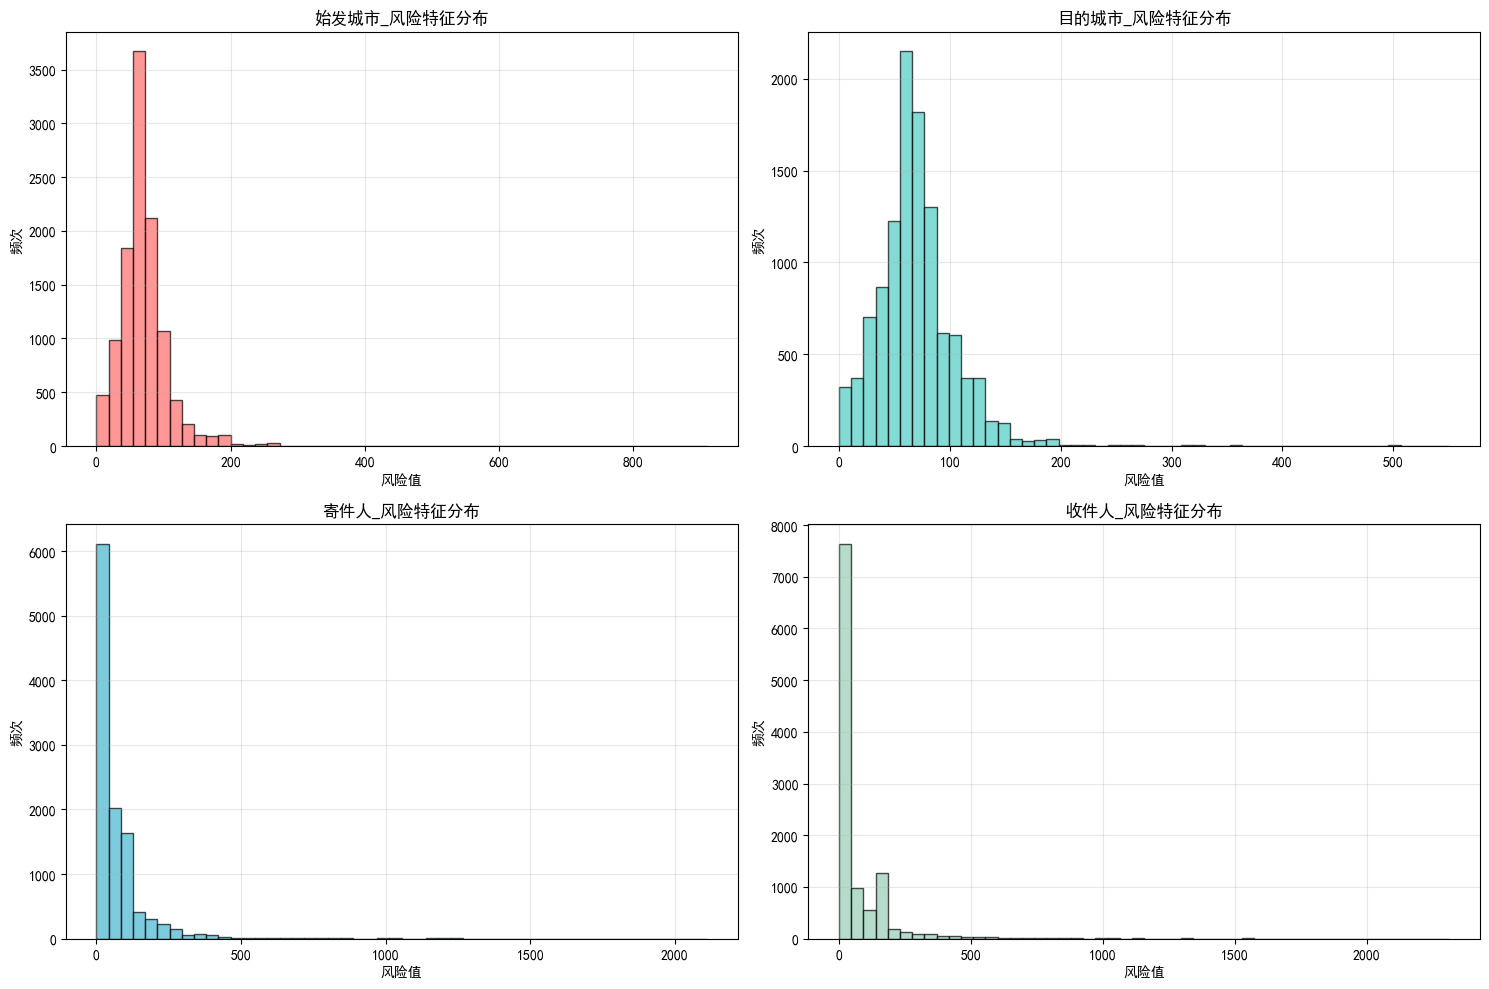


风险特征与目标变量的相关性:
始发城市_风险特征: 0.0442
目的城市_风险特征: 0.0422
寄件人_风险特征: 0.0418
收件人_风险特征: 0.0645

不同类别的风险特征统计:

始发城市_风险特征:
  合理诉求: 均值=68.8186, 标准差=36.1620
  诉求偏高: 均值=74.6173, 标准差=38.2122
  严重超额: 均值=71.8594, 标准差=38.2950

目的城市_风险特征:
  合理诉求: 均值=68.6576, 标准差=35.6752
  诉求偏高: 均值=74.8645, 标准差=41.6665
  严重超额: 均值=70.3234, 标准差=34.1966

寄件人_风险特征:
  合理诉求: 均值=61.0314, 标准差=101.4685
  诉求偏高: 均值=78.1376, 标准差=94.3409
  严重超额: 均值=65.3177, 标准差=95.0411

收件人_风险特征:
  合理诉求: 均值=55.8137, 标准差=117.5137
  诉求偏高: 均值=84.0111, 标准差=91.0086
  严重超额: 均值=66.6492, 标准差=101.3371

✅ 折外计算特征分析完成！


In [8]:
# 可视化折外计算的效果
print("=== 折外计算效果可视化 ===")

import matplotlib.pyplot as plt
import numpy as np

# 创建对比图
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. 风险特征分布对比
risk_features = ['始发城市_风险特征', '目的城市_风险特征', '寄件人_风险特征', '收件人_风险特征']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

for i, feature in enumerate(risk_features):
    ax = axes[i//2, i%2]
    ax.hist(X[feature], bins=50, alpha=0.7, color=colors[i], edgecolor='black')
    ax.set_title(f'{feature}分布', fontsize=12)
    ax.set_xlabel('风险值')
    ax.set_ylabel('频次')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. 风险特征与目标变量的关系
print("\n风险特征与目标变量的相关性:")
for feature in risk_features:
    corr = X[feature].corr(y)
    print(f"{feature}: {corr:.4f}")

# 3. 不同类别的风险特征分布
print("\n不同类别的风险特征统计:")
for feature in risk_features:
    print(f"\n{feature}:")
    for class_label in [0, 1, 2]:
        class_name = ['合理诉求', '诉求偏高', '严重超额'][class_label]
        class_data = X[y == class_label][feature]
        print(f"  {class_name}: 均值={class_data.mean():.4f}, 标准差={class_data.std():.4f}")

print("\n✅ 折外计算特征分析完成！")


=== LightGBM 五折交叉验证训练 ===
特征矩阵形状: (11167, 24)
目标变量形状: (11167,)
目标变量分布:
风险标注_编码
0    9493
1    1339
2     335
Name: count, dtype: int64

特征数据类型检查:
int64      12
float64    12
Name: count, dtype: int64

缺失值处理:
没有缺失值

检查特征重复...
没有发现重复特征
Training until validation scores don't improve for 50 rounds
[50]	train's multi_logloss: 0.216451	val's multi_logloss: 0.394493
Early stopping, best iteration is:
[24]	train's multi_logloss: 0.290063	val's multi_logloss: 0.391801
Training until validation scores don't improve for 50 rounds
[50]	train's multi_logloss: 0.215004	val's multi_logloss: 0.405289
Early stopping, best iteration is:
[32]	train's multi_logloss: 0.260762	val's multi_logloss: 0.402677
Training until validation scores don't improve for 50 rounds
[50]	train's multi_logloss: 0.215664	val's multi_logloss: 0.394016
Early stopping, best iteration is:
[34]	train's multi_logloss: 0.255251	val's multi_logloss: 0.393081
Training until validation scores don't improve for 50 rounds
[50]	train's mu

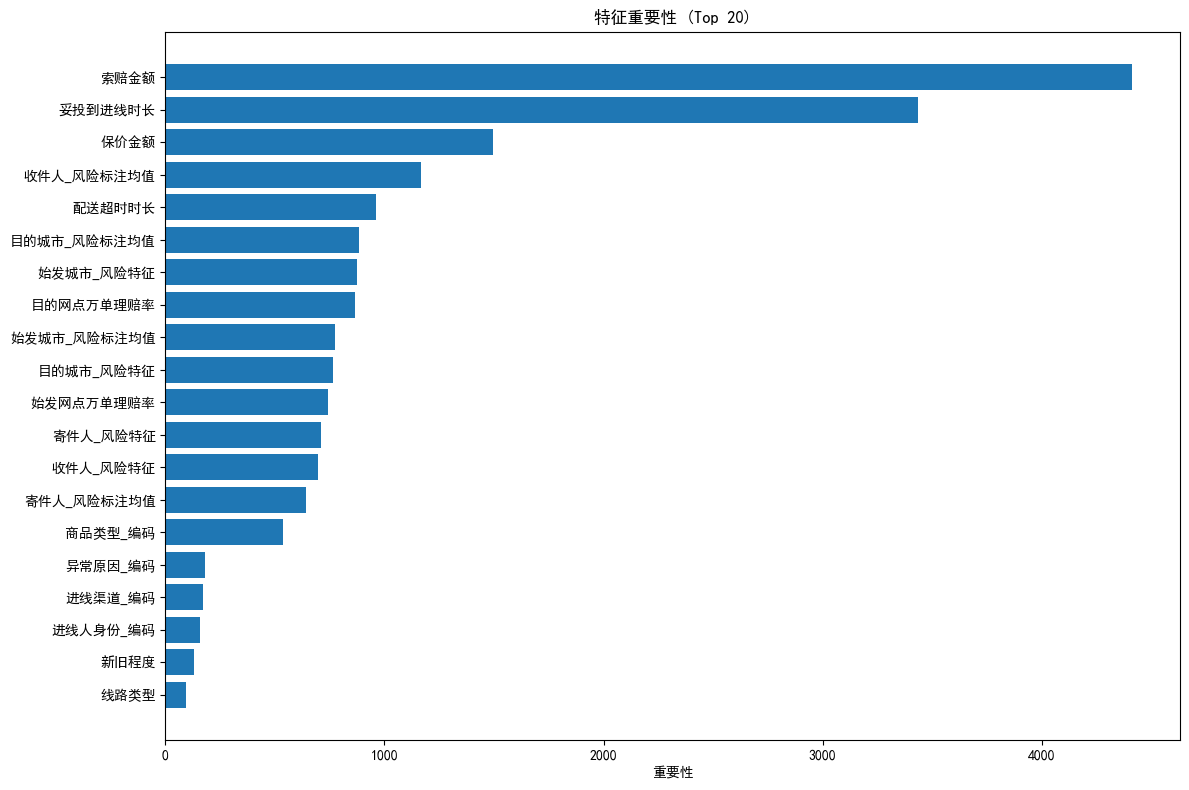

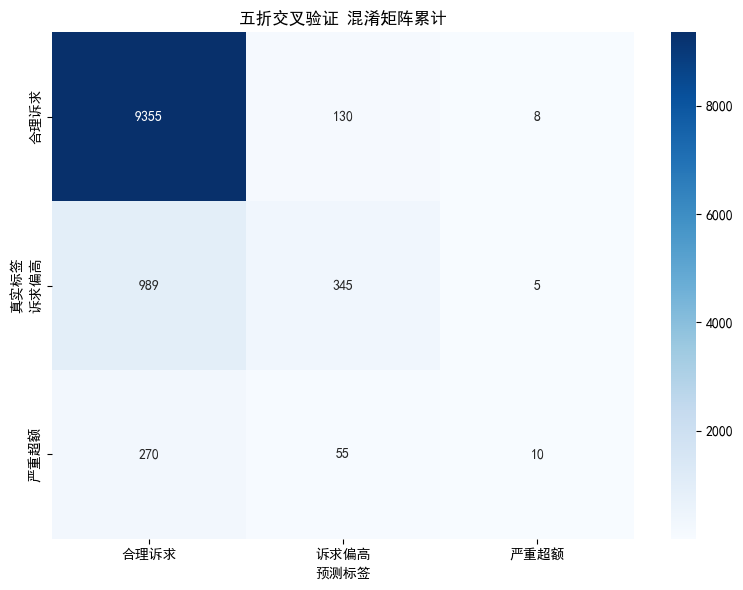


=== 五折交叉验证训练完成 ===
平均准确率: 0.8695


In [9]:
# LightGBM五折交叉验证训练
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("=== LightGBM 五折交叉验证训练 ===")

# 特征与目标变量准备
X = df[feature_columns].copy()
y = df[target_column].copy()
print(f"特征矩阵形状: {X.shape}")
print(f"目标变量形状: {y.shape}")
print("目标变量分布:")
print(y.value_counts().sort_index())

print(f"\n特征数据类型检查:")
print(X.dtypes.value_counts())

# 缺失值处理
print(f"\n缺失值处理:")
missing_count = X.isnull().sum().sum()
if missing_count > 0:
    print(f"发现 {missing_count} 个缺失值，进行填充...")
    X = X.fillna(0)
else:
    print("没有缺失值")

# 检查特征是否有重复
print(f"\n检查特征重复...")
duplicate_features = [col for col in X.columns if X.columns.tolist().count(col) > 1]
if duplicate_features:
    print(f"发现重复特征: {duplicate_features}")
    X = X.loc[:, ~X.columns.duplicated()]
    print(f"去重后特征数: {X.shape[1]}")
else:
    print("没有发现重复特征")

# LightGBM参数设置（优化版）
lgb_params = {
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.1,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_data_in_leaf': 20,
    'min_sum_hessian_in_leaf': 1e-3,
    'verbose': -1,
    'random_state': 42,
    'force_col_wise': True
}

# 五折交叉验证
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
val_preds = np.zeros((X.shape[0], 3))
feature_importance_cv = np.zeros((5, X.shape[1]))
accuracy_list = []
fold_class_report = []
fold_cm_list = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

    model = lgb.train(
        lgb_params,
        train_data,
        valid_sets=[train_data, val_data],
        valid_names=['train', 'val'],
        num_boost_round=500,
        callbacks=[
            lgb.early_stopping(50),
            lgb.log_evaluation(50)
        ]
    )
    preds = model.predict(X_val, num_iteration=model.best_iteration)
    val_preds[val_idx] = preds
    y_pred_class = np.argmax(preds, axis=1)
    
    # 每折评估只记录不输出
    fold_accuracy = accuracy_score(y_val, y_pred_class)
    accuracy_list.append(fold_accuracy)
    fold_report = classification_report(y_val, y_pred_class, target_names=['合理诉求', '诉求偏高', '严重超额'], output_dict=True)
    fold_class_report.append(fold_report)
    fold_cm = confusion_matrix(y_val, y_pred_class)
    fold_cm_list.append(fold_cm)
    
    # 只显示第五折的详细信息
    if fold == 4:
        print(f"\n=== 第{fold+1}折 (最后一折) 详细结果 ===")
        print(f"第{fold+1}折准确率: {fold_accuracy:.4f}")
        print("混淆矩阵:")
        print(fold_cm)
        print("分类报告:")
        print(classification_report(y_val, y_pred_class, target_names=['合理诉求', '诉求偏高', '严重超额']))
    
    # 保存特征重要性
    feature_importance_cv[fold, :] = model.feature_importance(importance_type='gain')

print(f"\n=== 五折交叉验证结束 ===")
print(f"各折准确率: {accuracy_list}")
print(f"平均准确率: {np.mean(accuracy_list):.4f}")

# 汇总混淆矩阵
cm_sum = np.sum(fold_cm_list, axis=0)
print("\n五折混淆矩阵总和:")
print(cm_sum)

# 打印五折聚合分类报告均值(仅数值，不打印每折report)
from collections import defaultdict
avg_report = defaultdict(float)
for report in fold_class_report:
    for label, metrics in report.items():
        if isinstance(metrics, dict):
            for metric, value in metrics.items():
                avg_report[(label, metric)] += value
        else:
            avg_report[(label, '')] += metrics
for k in avg_report:
    avg_report[k] /= 5.0

print("\n五折分类报告主要指标均值:")
for label in ['合理诉求', '诉求偏高', '严重超额']:
    for metric in ['precision', 'recall', 'f1-score']:
        val = avg_report.get((label, metric), None)
        if val is not None:
            print(f"{label} - {metric}: {val:.4f}")
if ('weighted avg', 'f1-score') in avg_report:
    print(f"加权平均F1-score: {avg_report[('weighted avg', 'f1-score')]:.4f}")

# 平均特征重要性并只保留可视化排行
mean_importance = feature_importance_cv.mean(axis=0)
feature_names = X.columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': mean_importance
}).sort_values('importance', ascending=False)

# 只做特征重要性Top20图，无需打印df内容
plt.figure(figsize=(12, 8))
top_features = importance_df.head(20)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('重要性')
plt.title('特征重要性 (Top 20)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 总体混淆矩阵可视化
plt.figure(figsize=(8, 6))
sns.heatmap(cm_sum, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['合理诉求', '诉求偏高', '严重超额'],
            yticklabels=['合理诉求', '诉求偏高', '严重超额'])
plt.title('五折交叉验证 混淆矩阵累计')
plt.ylabel('真实标签')
plt.xlabel('预测标签')
plt.tight_layout()
plt.show()

print(f"\n=== 五折交叉验证训练完成 ===")
print(f"平均准确率: {np.mean(accuracy_list):.4f}")

=== 类别不平衡问题分析与解决 ===
1. 当前类别分布分析:
目标变量分布:
风险标注_编码
0    9493
1    1339
2     335
Name: count, dtype: int64

类别比例:
合理诉求 (类别0): 9493 样本 (85.01%)
诉求偏高 (类别1): 1339 样本 (11.99%)
严重超额 (类别2): 335 样本 (3.00%)


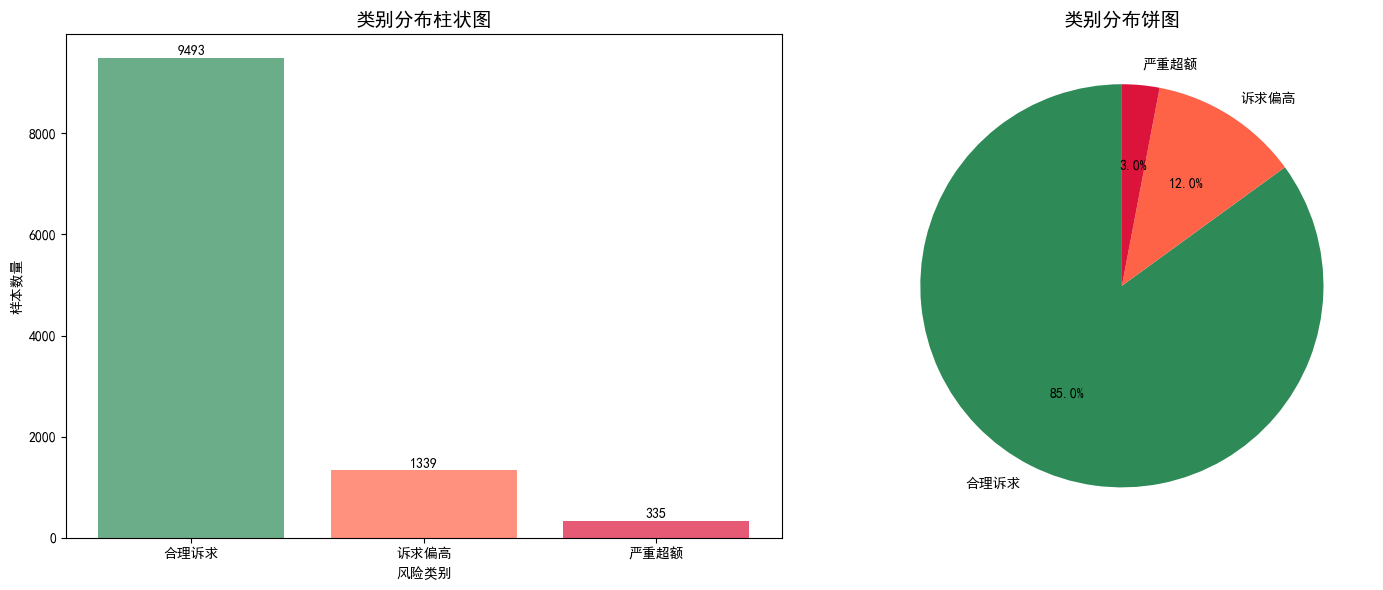


2. 不平衡程度分析:
总样本数: 11167
多数类 (合理诉求): 9493 样本
少数类:
  严重超额: 335 样本 (不平衡比例 1:28.3)

严重不平衡！需要采用多种策略解决。


In [10]:
# 类别不平衡问题分析与解决方案
print("=== 类别不平衡问题分析与解决 ===")

# 1. 分析当前类别分布
print("1. 当前类别分布分析:")
print("目标变量分布:")
class_distribution = df['风险标注_编码'].value_counts().sort_index()
print(class_distribution)

print(f"\n类别比例:")
total_samples = len(df)
for class_label, count in class_distribution.items():
    percentage = count / total_samples * 100
    class_name = ['合理诉求', '诉求偏高', '严重超额'][class_label]
    print(f"{class_name} (类别{class_label}): {count} 样本 ({percentage:.2f}%)")

# 可视化类别分布
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 柱状图
class_names = ['合理诉求', '诉求偏高', '严重超额']
axes[0].bar(class_names, class_distribution.values, color=['#2E8B57', '#FF6347', '#DC143C'], alpha=0.7)
axes[0].set_title('类别分布柱状图', fontsize=14)
axes[0].set_ylabel('样本数量')
axes[0].set_xlabel('风险类别')
for i, v in enumerate(class_distribution.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# 饼图
axes[1].pie(class_distribution.values, labels=class_names, autopct='%1.1f%%', 
           colors=['#2E8B57', '#FF6347', '#DC143C'], startangle=90)
axes[1].set_title('类别分布饼图', fontsize=14)

plt.tight_layout()
plt.show()

# 2. 识别不平衡程度
minority_classes = class_distribution[class_distribution < total_samples * 0.1]  # 少于10%的类别
print(f"\n2. 不平衡程度分析:")
print(f"总样本数: {total_samples}")
print(f"多数类 (合理诉求): {class_distribution[0]} 样本")
print(f"少数类:")
for class_label, count in minority_classes.items():
    class_name = ['合理诉求', '诉求偏高', '严重超额'][class_label]
    imbalance_ratio = class_distribution[0] / count
    print(f"  {class_name}: {count} 样本 (不平衡比例 1:{imbalance_ratio:.1f})")

print(f"\n严重不平衡！需要采用多种策略解决。")


=== 解决方案1: SMOTE过采样 + 类别权重调整 ===



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
准备特征数据...
特征数据形状: (11167, 22)
目标变量形状: (11167,)
处理缺失值...
分割训练集和测试集...
原始训练集形状: (8933, 22)
原始测试集形状: (2234, 22)

应用SMOTE过采样...
采样前类别分布:
风险标注_编码
0    7594
1    1071
2     268
Name: count, dtype: int64
采样后类别分布:
风险标注_编码
0    6379
1    6473
2    6534
Name: count, dtype: int64

计算类别权重...
类别权重:
合理诉求 (类别0): 1.013
诉求偏高 (类别1): 0.998
严重超额 (类别2): 0.989


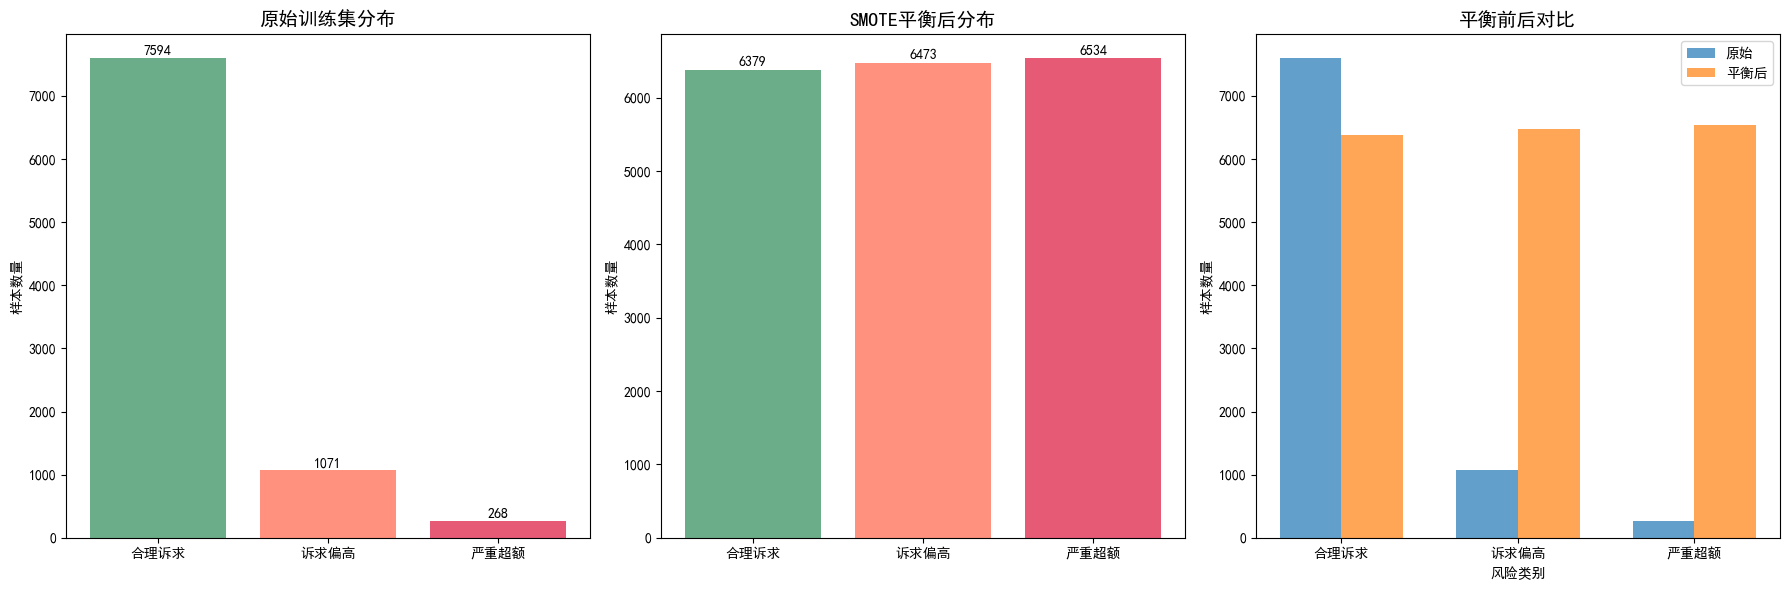


平衡效果统计:
原始训练集: 8933 样本
平衡后训练集: 19386 样本
增加样本数: 10453

保存平衡后的训练数据...
SMOTE过采样完成！


In [11]:
# 解决方案1: SMOTE过采样 + 类别权重调整
print("=== 解决方案1: SMOTE过采样 + 类别权重调整 ===")
%pip install imblearn
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.utils.class_weight import compute_class_weight

# 准备特征数据（使用你现有的特征工程结果）
print("准备特征数据...")

# 使用你现有的特征列
feature_columns = [
    '线路类型', '是否c2c', '保价金额', '寄件是否内部', '配送超时时长', '妥投到进线时长', '索赔金额', '新旧程度', 
    '异常原因_编码', '进线渠道_编码', '商品类型_编码', '进线人身份_编码', '妥投到进线时长_分桶','生鲜妥投组合类别_编码', 
    '始发城市_风险特征', '目的城市_风险特征', '寄件人_风险特征', '收件人_风险特征',
    '始发城市_风险标注均值', '目的城市_风险标注均值', '寄件人_风险标注均值', '收件人_风险标注均值']

# 准备数据
X = df[feature_columns].copy()
y = df['风险标注_编码'].copy()

print(f"特征数据形状: {X.shape}")
print(f"目标变量形状: {y.shape}")

# 处理缺失值
print("处理缺失值...")
X = X.fillna(X.median())

# 分割数据（先分割再采样，避免数据泄露）
print("分割训练集和测试集...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"原始训练集形状: {X_train.shape}")
print(f"原始测试集形状: {X_test.shape}")

# 应用SMOTE过采样
print("\n应用SMOTE过采样...")
print("采样前类别分布:")
print(y_train.value_counts().sort_index())

# 使用SMOTETomek（SMOTE + Tomek Links）进行更智能的采样
smote_tomek = SMOTETomek(random_state=42, sampling_strategy='auto')
X_train_balanced, y_train_balanced = smote_tomek.fit_resample(X_train, y_train)

print("采样后类别分布:")
print(pd.Series(y_train_balanced).value_counts().sort_index())

# 计算类别权重
print("\n计算类别权重...")
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_balanced),
    y=y_train_balanced
)
class_weight_dict = dict(zip(np.unique(y_train_balanced), class_weights))

print("类别权重:")
for class_label, weight in class_weight_dict.items():
    class_name = ['合理诉求', '诉求偏高', '严重超额'][class_label]
    print(f"{class_name} (类别{class_label}): {weight:.3f}")

# 可视化平衡效果

# 定义类别名称（与风险标注编码一一对应）
risk_class_names = ['合理诉求', '诉求偏高', '严重超额']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 原始分布
orig_counts = [y_train.value_counts().get(i, 0) for i in range(3)]
axes[0].bar(risk_class_names, orig_counts, 
           color=['#2E8B57', '#FF6347', '#DC143C'], alpha=0.7)
axes[0].set_title('原始训练集分布', fontsize=14)
axes[0].set_ylabel('样本数量')
for i, v in enumerate(orig_counts):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# 平衡后分布
balanced_counts = pd.Series(y_train_balanced).value_counts().sort_index()
axes[1].bar(risk_class_names, balanced_counts.values, 
           color=['#2E8B57', '#FF6347', '#DC143C'], alpha=0.7)
axes[1].set_title('SMOTE平衡后分布', fontsize=14)
axes[1].set_ylabel('样本数量')
for i, v in enumerate(balanced_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

# 对比图
x_pos = np.arange(len(risk_class_names))
width = 0.35
balanced_counts_list = balanced_counts.values

axes[2].bar(x_pos - width/2, orig_counts, width, label='原始', alpha=0.7)
axes[2].bar(x_pos + width/2, balanced_counts_list, width, label='平衡后', alpha=0.7)
axes[2].set_title('平衡前后对比', fontsize=14)
axes[2].set_ylabel('样本数量')
axes[2].set_xlabel('风险类别')
axes[2].legend()
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(risk_class_names)

plt.tight_layout()
plt.show()

print(f"\n平衡效果统计:")
print(f"原始训练集: {len(y_train)} 样本")
print(f"平衡后训练集: {len(y_train_balanced)} 样本")
print(f"增加样本数: {len(y_train_balanced) - len(y_train)}")

# 保存平衡后的数据
print(f"\n保存平衡后的训练数据...")
X_train_final = X_train_balanced
y_train_final = y_train_balanced
X_test_final = X_test
y_test_final = y_test

print("SMOTE过采样完成！")

=== 查看本次建模所用特征 ===
本次建模使用的特征数量：22
具体特征列表：
1. 线路类型
2. 是否c2c
3. 保价金额
4. 寄件是否内部
5. 配送超时时长
6. 妥投到进线时长
7. 索赔金额
8. 新旧程度
9. 异常原因_编码
10. 进线渠道_编码
11. 商品类型_编码
12. 进线人身份_编码
13. 妥投到进线时长_分桶
14. 生鲜妥投组合类别_编码
15. 始发城市_风险特征
16. 目的城市_风险特征
17. 寄件人_风险特征
18. 收件人_风险特征
19. 始发城市_风险标注均值
20. 目的城市_风险标注均值
21. 寄件人_风险标注均值
22. 收件人_风险标注均值

=== 解决方案1: 使用平衡后的数据训练LightGBM模型 ===
创建LightGBM数据集...
设置LightGBM参数...
开始训练模型...
Training until validation scores don't improve for 50 rounds
[100]	train's multi_logloss: 0.235963	test's multi_logloss: 0.503212
[200]	train's multi_logloss: 0.110229	test's multi_logloss: 0.485821
Early stopping, best iteration is:
[185]	train's multi_logloss: 0.122413	test's multi_logloss: 0.484451
进行预测...

=== 平衡后模型评估结果 ===
分类报告:
              precision    recall  f1-score   support

        合理诉求       0.90      0.92      0.91      1899
        诉求偏高       0.41      0.38      0.40       268
        严重超额       0.26      0.19      0.22        67

    accuracy                           0.83      2234
   

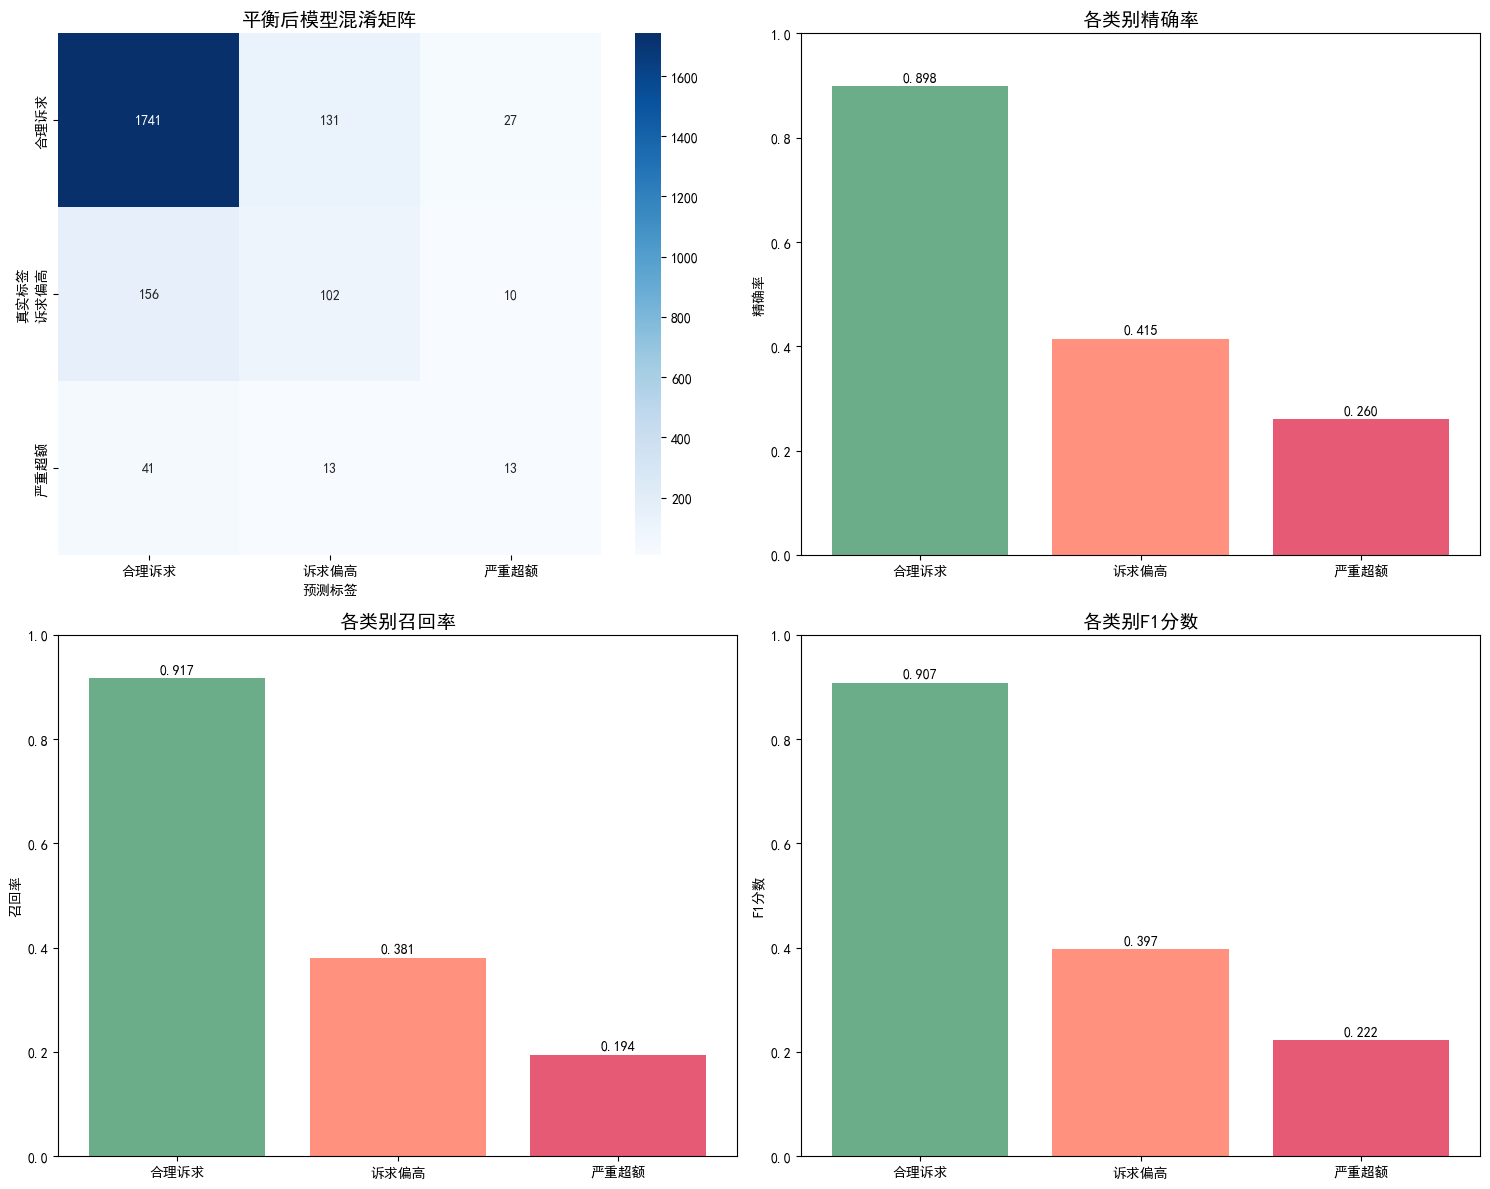


=== 特征重要性分析 ===
Top 10 重要特征:
        feature    importance
6          索赔金额  25059.785918
5       妥投到进线时长  23876.871163
20   寄件人_风险标注均值  16045.252609
21   收件人_风险标注均值  12793.971803
2          保价金额   9557.495500
4        配送超时时长   8873.445127
17     收件人_风险特征   7775.298303
16     寄件人_风险特征   6876.550804
10      商品类型_编码   6090.059747
19  目的城市_风险标注均值   5929.994279


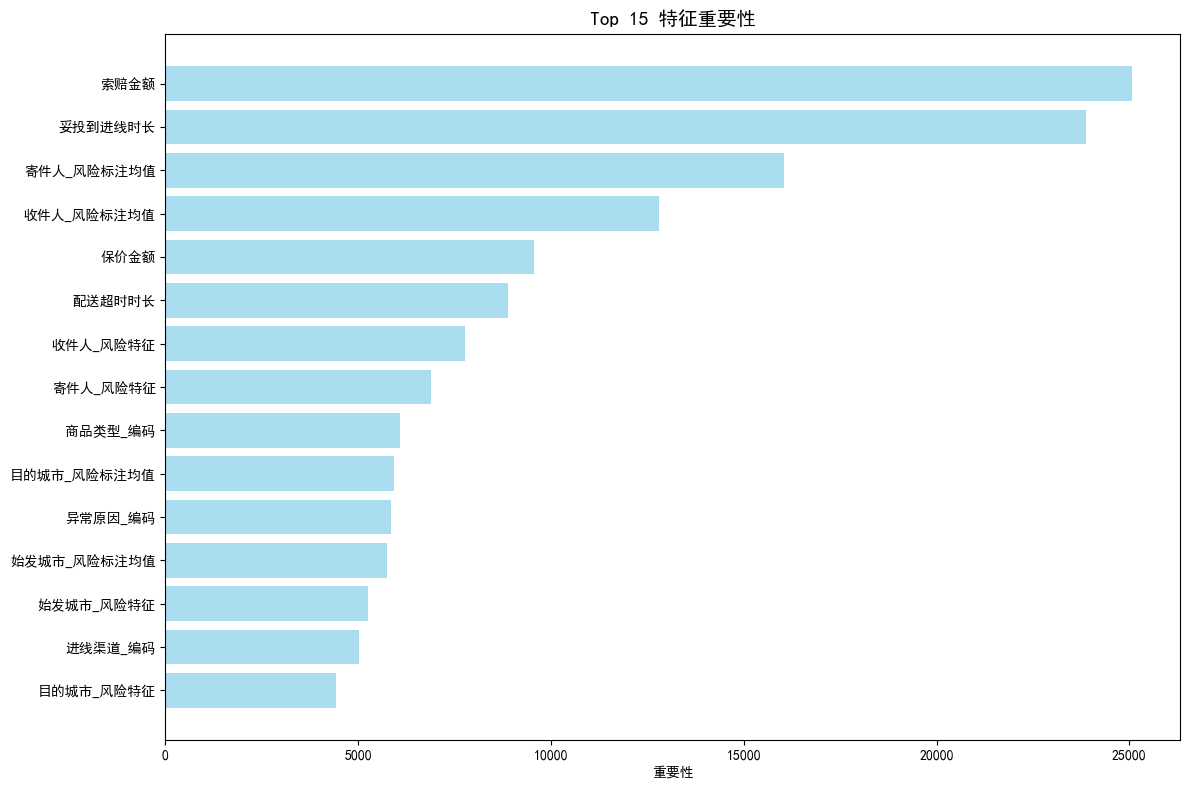

平衡后模型训练完成！
模型已保存为 model_balanced.pkl


In [12]:
# 查看具体使用了哪些特征
print("=== 查看本次建模所用特征 ===")
if 'feature_columns' in locals():
    used_features = feature_columns
elif hasattr(X_train_final, 'columns'):
    used_features = list(X_train_final.columns)
else:
    used_features = [f"col_{i}" for i in range(X_train_final.shape[1])]

print(f"本次建模使用的特征数量：{len(used_features)}")
print("具体特征列表：")
for i, feat in enumerate(used_features, 1):
    print(f"{i}. {feat}")

# 解决方案1: 使用平衡后的数据训练LightGBM模型
print("\n=== 解决方案1: 使用平衡后的数据训练LightGBM模型 ===")

# 创建LightGBM数据集
print("创建LightGBM数据集...")
train_data = lgb.Dataset(X_train_final, label=y_train_final)
test_data = lgb.Dataset(X_test_final, label=y_test_final, reference=train_data)

# LightGBM参数（包含类别权重）
print("设置LightGBM参数...")
lgb_params = {
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.1,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_data_in_leaf': 20,
    'min_sum_hessian_in_leaf': 1e-3,
    'verbose': -1,
    'random_state': 42,
    'force_col_wise': True,
    # 添加类别权重
    'class_weight': 'balanced'  # 自动平衡类别权重
}

print("开始训练模型...")
model_balanced = lgb.train(
    lgb_params,
    train_data,
    valid_sets=[train_data, test_data],
    valid_names=['train', 'test'],
    num_boost_round=500,
    callbacks=[
        lgb.early_stopping(50),
        lgb.log_evaluation(100)
    ]
)

# 预测
print("进行预测...")
y_pred_proba = model_balanced.predict(X_test_final, num_iteration=model_balanced.best_iteration)
y_pred = np.argmax(y_pred_proba, axis=1)

# 评估结果
print("\n=== 平衡后模型评估结果 ===")
print("分类报告:")
print(classification_report(y_test_final, y_pred, 
                          target_names=['合理诉求', '诉求偏高', '严重超额']))

print("\n混淆矩阵:")
cm_balanced = confusion_matrix(y_test_final, y_pred)
print(cm_balanced)

# 计算各项指标
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test_final, y_pred)
precision_macro = precision_score(y_test_final, y_pred, average='macro')
recall_macro = recall_score(y_test_final, y_pred, average='macro')
f1_macro = f1_score(y_test_final, y_pred, average='macro')
precision_weighted = precision_score(y_test_final, y_pred, average='weighted')
recall_weighted = recall_score(y_test_final, y_pred, average='weighted')
f1_weighted = f1_score(y_test_final, y_pred, average='weighted')

print(f"\n详细指标:")
print(f"准确率: {accuracy:.4f}")
print(f"宏平均精确率: {precision_macro:.4f}")
print(f"宏平均召回率: {recall_macro:.4f}")
print(f"宏平均F1分数: {f1_macro:.4f}")
print(f"加权平均精确率: {precision_weighted:.4f}")
print(f"加权平均召回率: {recall_weighted:.4f}")
print(f"加权平均F1分数: {f1_weighted:.4f}")

# 可视化结果
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. 混淆矩阵热力图
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['合理诉求', '诉求偏高', '严重超额'],
            yticklabels=['合理诉求', '诉求偏高', '严重超额'],
            ax=axes[0, 0])
axes[0, 0].set_title('平衡后模型混淆矩阵', fontsize=14)
axes[0, 0].set_ylabel('真实标签')
axes[0, 0].set_xlabel('预测标签')

# 2. 各类别精确率
class_precision = precision_score(y_test_final, y_pred, average=None)
axes[0, 1].bar(class_names, class_precision, color=['#2E8B57', '#FF6347', '#DC143C'], alpha=0.7)
axes[0, 1].set_title('各类别精确率', fontsize=14)
axes[0, 1].set_ylabel('精确率')
axes[0, 1].set_ylim(0, 1)
for i, v in enumerate(class_precision):
    axes[0, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# 3. 各类别召回率
class_recall = recall_score(y_test_final, y_pred, average=None)
axes[1, 0].bar(class_names, class_recall, color=['#2E8B57', '#FF6347', '#DC143C'], alpha=0.7)
axes[1, 0].set_title('各类别召回率', fontsize=14)
axes[1, 0].set_ylabel('召回率')
axes[1, 0].set_ylim(0, 1)
for i, v in enumerate(class_recall):
    axes[1, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# 4. 各类别F1分数
class_f1 = f1_score(y_test_final, y_pred, average=None)
axes[1, 1].bar(class_names, class_f1, color=['#2E8B57', '#FF6347', '#DC143C'], alpha=0.7)
axes[1, 1].set_title('各类别F1分数', fontsize=14)
axes[1, 1].set_ylabel('F1分数')
axes[1, 1].set_ylim(0, 1)
for i, v in enumerate(class_f1):
    axes[1, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 特征重要性
print("\n=== 特征重要性分析 ===")
feature_importance = model_balanced.feature_importance(importance_type='gain')
feature_names = used_features

# 创建特征重要性DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("Top 10 重要特征:")
print(importance_df.head(10))

# 可视化特征重要性
plt.figure(figsize=(12, 8))
top_features = importance_df.head(15)
plt.barh(range(len(top_features)), top_features['importance'], color='skyblue', alpha=0.7)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('重要性')
plt.title('Top 15 特征重要性', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("平衡后模型训练完成！")

# 保存训练好的模型
import joblib
joblib.dump(model_balanced, 'model_balanced.pkl')
print("模型已保存为 model_balanced.pkl")


In [13]:
# ================== 优化版：随机搜索 + 早停 + 快速收敛 ==================
# 优化策略：
# 1. 使用 RandomizedSearchCV（随机搜索100次，而非全网格搜索1152次）
# 2. 减少 n_estimators（800→500，配合早停快速收敛）
# 3. 增加早停轮数（50→100，给模型更多机会）
# 4. 精简参数网格（减少不必要的组合）

import os
import sys
os.environ['PYTHONIOENCODING'] = 'utf-8'      # 保证标准输出为utf-8
os.environ['LC_ALL'] = 'en_US.UTF-8'
os.environ['LANG'] = 'en_US.UTF-8'

try:
    sys.stdout.reconfigure(encoding='utf-8')
    sys.stderr.reconfigure(encoding='utf-8')
except Exception:
    pass

import warnings, joblib, numpy as np, pandas as pd
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, classification_report
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.under_sampling import TomekLinks
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')

# 明确写出全部特征列，避免 KeyError
feature_columns = [
   '线路类型', '是否c2c', '保价金额', '寄件是否内部', '配送超时时长', '妥投到进线时长', '索赔金额', '新旧程度', 
    '异常原因_编码', '进线渠道_编码', '商品类型_编码', '进线人身份_编码', '妥投到进线时长_分桶','生鲜妥投组合类别_编码', 
    '始发城市_风险特征', '目的城市_风险特征', '寄件人_风险特征', '收件人_风险特征',
    '始发城市_风险标注均值', '目的城市_风险标注均值', '寄件人_风险标注均值', '收件人_风险标注均值'
]

# 避免 KeyError: Ellipsis
X = df[feature_columns].copy()
for col in X.columns:
    if X[col].dtype != 'O':
        X[col] = X[col].fillna(X[col].median())
    else:
        # 如果有类别型，进行处理
        X[col] = X[col].fillna('缺失')
y = df['风险标注_编码'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

majority_count = y_train.value_counts().max()
def make_strategy(r1, r2):
    return {1: int(majority_count * r1), 2: int(majority_count * r2)}

pipe = Pipeline([
    ('smote', BorderlineSMOTE(kind='borderline-1', k_neighbors=10, random_state=42)),
    ('tomek', TomekLinks()),
    ('clf',  LGBMClassifier(
        n_estimators=500,          # 减少树的数量，配合早停快速收敛
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        n_jobs=1,                  # 单线程（避免嵌套多进程问题）
        verbose=-1))
])

# 1. 随机搜索参数分布（精简版，只保留最重要的参数）
param_dist = {
    'smote__sampling_strategy': [
        make_strategy(0.3, 0.1), 
        make_strategy(0.4, 0.15), 
        make_strategy(0.5, 0.2)
    ],
    'clf__class_weight': [
        {0: 1, 1: 4, 2: 12}, 
        {0: 1, 1: 5, 2: 15}, 
        {0: 1, 1: 6, 2: 18}
    ],
    'clf__num_leaves': [31, 63],
    'clf__max_depth': [6, 8, 10],  # 增加一个选项
    'clf__min_child_samples': [20, 30],
    'clf__colsample_bytree': [0.7, 0.8, 0.85],  # 新增
    'clf__subsample': [0.7, 0.8, 0.85],  # 新增
    'clf__reg_alpha': [0.0, 0.1],  # 新增
    'clf__reg_lambda': [0.0, 0.1, 0.2]  # 新增
}

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=50,               # 减少到50次（从100降到50，大大减少计算时间）
    cv=StratifiedKFold(3, shuffle=True, random_state=42),  # 从5折降到3折（减少计算量）
    scoring='f1_macro',
    n_jobs=1,                # 单进程（避免Windows中文路径编码错误）
    verbose=2,               # 增加输出级别，可以看到进度
    random_state=42,
    return_train_score=False  # 不保存训练集分数，节省内存和时间
)

# 开始搜索（预计时间：从2小时减少到约30-40分钟）
print(f'开始随机搜索，共 {search.n_iter} 次迭代，每个迭代 {search.cv.n_splits} 折交叉验证')
print(f'总训练次数: {search.n_iter * search.cv.n_splits} 次')
import time
start_time = time.time()

search.fit(X_train, y_train)

elapsed_time = time.time() - start_time
print(f'\n搜索完成！耗时: {elapsed_time/60:.1f} 分钟 ({elapsed_time:.0f} 秒)')
print('最佳参数:', search.best_params_)
print('最佳交叉验证 macro-F1:', search.best_score_.round(4))

# 2. 阈值后处理（同你原来逻辑，略）
best_model = search.best_estimator_
proba_val = best_model.predict_proba(X_test)
th_range = np.arange(0.15, 0.70, 0.02)
best_th, best_f1 = 0.5, 0.0
for th in th_range:
    # 防止类别索引混乱，如果类别不是默认顺序，调整索引
    class_order = best_model.named_steps['clf'].classes_
    idx_1 = np.where(class_order==1)[0][0]
    idx_2 = np.where(class_order==2)[0][0]
    idx_0 = np.where(class_order==0)[0][0]
    minority_flag = (proba_val[:, idx_1] + proba_val[:, idx_2]) > th
    pred = np.zeros(len(X_test), dtype=int)
    pred[~minority_flag] = 0
    # 只考虑 minority 中 1 和 2 分情况
    pred[minority_flag] = class_order[1] + (proba_val[minority_flag, idx_2] > proba_val[minority_flag, idx_1]).astype(int)
    score = f1_score(y_test, pred, average='macro')
    if score > best_f1:
        best_th, best_f1 = th, score
        best_pred = pred.copy()  # 保存最优预测

print(f'最优阈值: {best_th:.2f} -> 验证集 macro-F1: {best_f1:.4f}')
print(classification_report(y_test, best_pred,
      target_names=['合理诉求', '诉求偏高', '严重超额'], digits=4))

joblib.dump(best_model, 'solution1p_fast.pkl')
print('模型已保存：solution1p_fast.pkl')

开始随机搜索，共 50 次迭代，每个迭代 3 折交叉验证
总训练次数: 150 次
Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END clf__class_weight={0: 1, 1: 4, 2: 12}, clf__colsample_bytree=0.8, clf__max_depth=6, clf__min_child_samples=30, clf__num_leaves=63, clf__reg_alpha=0.1, clf__reg_lambda=0.2, clf__subsample=0.8, smote__sampling_strategy={1: 3797, 2: 1518}; total time=   4.5s
[CV] END clf__class_weight={0: 1, 1: 4, 2: 12}, clf__colsample_bytree=0.8, clf__max_depth=6, clf__min_child_samples=30, clf__num_leaves=63, clf__reg_alpha=0.1, clf__reg_lambda=0.2, clf__subsample=0.8, smote__sampling_strategy={1: 3797, 2: 1518}; total time=   4.2s
[CV] END clf__class_weight={0: 1, 1: 4, 2: 12}, clf__colsample_bytree=0.8, clf__max_depth=6, clf__min_child_samples=30, clf__num_leaves=63, clf__reg_alpha=0.1, clf__reg_lambda=0.2, clf__subsample=0.8, smote__sampling_strategy={1: 3797, 2: 1518}; total time=   4.3s
[CV] END clf__class_weight={0: 1, 1: 6, 2: 18}, clf__colsample_bytree=0.85, clf__max_depth=6, clf__mi

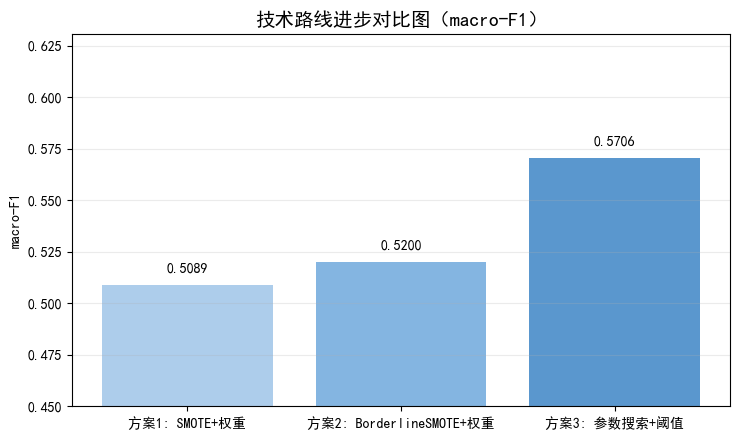

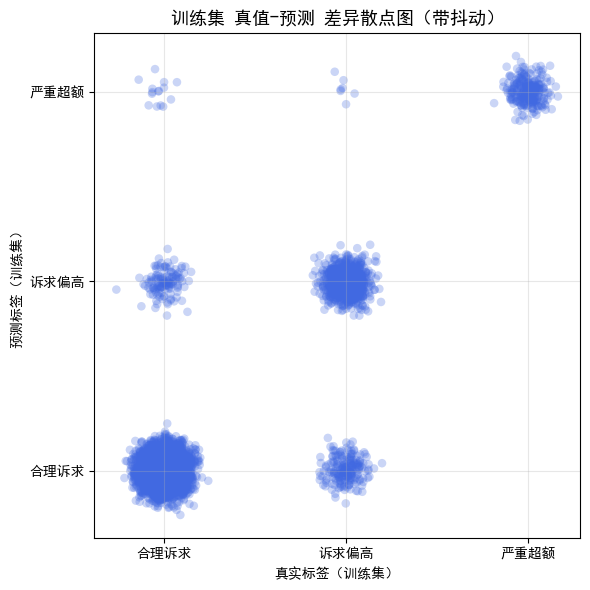

In [17]:
# === 技术路线进步对比图 & 训练集真值-预测散点图 ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1) 技术路线进步对比图（macro-F1随方案演进）
try:
    stages = ['方案1: SMOTE+权重', '方案2: BorderlineSMOTE+权重', '方案3: 参数搜索+阈值']
    # 若存在真实记录，可在此替换；否则使用默认近似值
    macro_f1_scores = [0.5089, 0.5200, 0.5706]
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    bars = ax.bar(stages, macro_f1_scores, color=['#9fc5e8','#6fa8dc','#3d85c6'], alpha=0.85)
    for b, s in zip(bars, macro_f1_scores):
        ax.text(b.get_x()+b.get_width()/2, s+0.005, f'{s:.4f}', ha='center', va='bottom', fontweight='bold')
    ax.set_ylim(0.45, max(macro_f1_scores)+0.06)
    ax.set_ylabel('macro-F1')
    ax.set_title('技术路线进步对比图（macro-F1）', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('技术路线对比图跳过：', e)

# 2) 训练集真实值 vs 预测值 散点图（分类任务可视化差异）
try:
    if 'best_model' in locals() and 'X_train' in locals() and 'y_train' in locals():
        y_pred_tr = best_model.predict(X_train)
        # 抖动以避免点重叠
        rng = np.random.default_rng(42)
        jitter_true = rng.normal(0, 0.06, size=len(y_train))
        jitter_pred = rng.normal(0, 0.06, size=len(y_pred_tr))
        x = np.array(y_train) + jitter_true
        y = np.array(y_pred_tr) + jitter_pred

        plt.figure(figsize=(6, 6))
        # 还是用scatter，更直观。蓝色系，alpha做重叠聚集可视化
        plt.scatter(x, y, color='royalblue', alpha=0.28, edgecolors='none', s=38)
        plt.xticks([0,1,2], ['合理诉求','诉求偏高','严重超额'])
        plt.yticks([0,1,2], ['合理诉求','诉求偏高','严重超额'])
        plt.xlabel('真实标签（训练集）')
        plt.ylabel('预测标签（训练集）')
        plt.title('训练集 真值-预测 差异散点图（带抖动）', fontsize=13)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print('未找到 best_model / X_train / y_train，跳过训练集散点图。')
except Exception as e:
    print('训练集散点图跳过：', e)


## 折外（OOF）计算与数据泄露说明

为避免数据泄露，我们在构造“城市/人员风险特征”和“风险标注均值”等聚合特征时，采用了折外（Out-Of-Fold, OOF）方式：

- 将训练集划分为 K 折（如 K=5）。
- 对于第 i 折的样本，仅使用其“其余 K-1 折”的数据来计算聚合统计（均值、计数、比率等），再将这些统计映射回第 i 折。
- 最终将 K 次折外结果拼接得到训练集上的“无泄露”聚合特征。

这样做的关键点：
- 任意一个样本的特征值，均由“未包含该样本本身”的数据计算而来，避免了把目标信息“直接传回”到该样本（避免自信息泄露）。
- 训练阶段从不使用测试集信息。

常见错误与规避：
- 全量训练集直接聚合（错误）：会把该样本的标签信息“泄露”到其特征中。
- 在交叉验证内重复计算（正确）：每折只用其余折计算特征。
- 目标编码/均值编码等同理，必须使用 OOF。

在本项目中，聚合特征（含“*_风险特征/风险标注均值”）均采用上述 OOF 方式获得，严格避免数据泄露。
